How digital word-of-mouth influences customr trust and purchase decisions

In [2]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.set(style="whitegrid")

<Figure size 600x400 with 0 Axes>

In [16]:
# Load Dataaset
df=pd.read_csv("WordOfMouth.csv")
df.head(10)

,Name,Age,Gender,What is the frequency of your online shopping?,Are you aware of the concept of word of mouth marketing in the digital age?,Which digital word of mouth platform do you trust the most for online reviews before making a purchase decision?,How often do you search for online reviews or opinions before purchasing a product?,How often do you check online discussion forums such as reddit or quora to read customer opinions before making a purchase decision?,"Do you believe that digital word of mouth (online reviews, recommendations and discussions) helps in building brands trust and credibility?","In your opinion, brands with higher online ratings and reviews are more trustworthy.",Does a brand's quick response to online reviews or customer complaints increase your trust in that brand?,Online reviews help reduce the risk involved in making purchase decision.,What motivates you the most to share product reviews.,How quickly do online reviews influence your final purchase.,Do you compare reviews across different websites
0,Prachi,Below 20,NaN,Occasionally (once a month),Yes,Video reviews and product demos,Always,Sometimes,Yes,Strongly agree,Yes,Strongly agree,Extremly positive or negative product experience,Immediately,Always
1,Preeti,21-30,Female,Frequently (2-3 times a month),Yes,Reviews on e commerce website,Often,Sometimes,Yes,Agree,Yes,Agree,Desire to help other customers,After some consideration,Sometimes
2,Alisha,21-30,Female,Rarely (once in a few months),Yes,Video reviews and product demos,Always,Never,Yes,Agree,Yes,Neutral,Extremly positive or negative product experience,After some consideration,Sometimes
3,Parneet Kaur,21-30,Female,Frequently (2-3 times a month),No,Video reviews and product demos,Always,Sometimes,Yes,Agree,Yes,Agree,Desire to help other customers,After some consideration,Sometimes
4,Mehak Walia,Below 20,Female,Never (I do not shop online),No,Brand pages with customer feedback,Sometimes,Rarely,No,Disagree,No,Disagree,Rewards or discounts,Rarely,Sometimes
5,Sneha Kundu,Below 20,Female,Frequently (2-3 times a month),No,Reviews on e commerce website,Always,Never,Yes,Agree,Yes,Strongly agree,Rewards or discounts,After some consideration,Always
6,Rajkamal Singh,21-30,Male,Very Frequently (once a week or more0,Yes,Social media posts,Always,Sometimes,Yes,Strongly agree,Yes,Strongly agree,Extremly positive or negative product experience,Immediately,Sometimes
7,Neha Sharma,21-30,Female,Occasionally (once a month),No,Brand pages with customer feedback,Sometimes,Rarely,Yes,Strongly disagree,No,Disagree,Desire to help other customers,After some consideration,Sometimes
8,Simran,21-30,Female,Occasionally (once a month),No,Video reviews and product demos,Always,Sometimes,Yes,Strongly agree,NaN,Agree,Desire to help other customers,After some consideration,Sometimes
9,Rishika Singla,Below 20,Female,Rarely (once in a few months),No,Video reviews and product demos,Often,Never,Yes,Agree,Yes,Agree,Desire to help other customers,After some consideration,Always


In [133]:
# Understanding Dataset
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 15 columns):
 #   Column                                                                                                                                       Non-Null Count  Dtype 
---  ------                                                                                                                                       --------------  ----- 
 0   Name                                                                                                                                         101 non-null    object
 1   Age                                                                                                                                          105 non-null    object
 2   Gender                                                                                                                                       104 non-null    object
 3   What is the frequency of your online shopping

In [4]:
# Data Cleaning
df.columns=df.columns.str.strip()

df.isnull().sum()

df=df.dropna()

In [5]:
df.fillna("Unknown", inplace=True)

In [6]:
for col in df.columns:
    df[col]=df[col].astype(str).str.strip().str.lower()

In [7]:
df.duplicated().sum()

0

In [67]:
df.rename(columns={'What is the frequency of your online shopping?':'Shopping_Frequency','Are you aware of the concept of word of mouth marketing in the digital age?':'WOM_Awareness','Which digital word of mouth platform do you trust the most for online reviews before making a purchase decision?':'trusted_platform','How often do you search for online reviews or opinions before purchasing a product?':'reviews','How often do you check online discussion forums such as reddit or quora to read customer opinions before making a purchase decision?':'forums','Do you believe that digital word of mouth (online reviews, recommendations and discussions) helps in building brands trust and credibility?':'trust_builded',"Does a brand's quick response to online reviews or customer complaints increase your trust in that brand?":'trust_builded4',"Online reviews help reduce the risk involved in making purchase decision.":'trust_builded2',"In your opinion, brands with higher online ratings and reviews are more trustworthy.":"trust_builded3"},inplace=True)
df.columns

Index(['Name', 'Age', 'Gender', 'Shopping_Frequency', 'WOM_Awareness',
       'trusted_platform', 'reviews', 'forums', 'trust_builded',
       'trust_builded3', 'trust_builded4', 'trust_builded2',
       'What motivates you the most to share product reviews.',
       'How quickly do online reviews influence your final purchase.',
       'Do you compare reviews across different websites'],
      dtype='object')

## Plotting

C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\1250161051.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


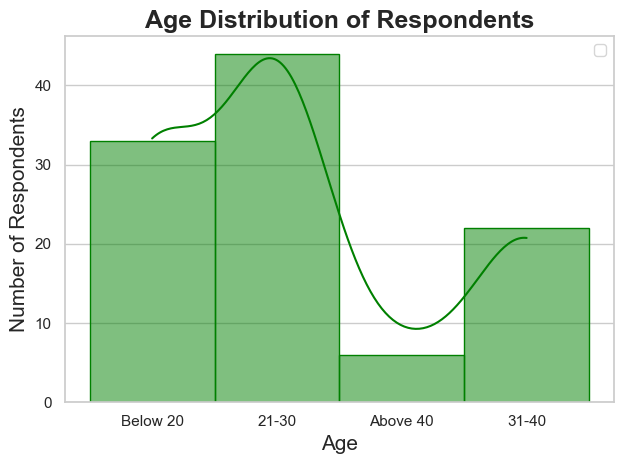

In [108]:
# 1. Age Distribution
sns.histplot(df,x='Age',color="green",edgecolor='green',bins=10,kde=True)
plt.title("Age Distribution of Respondents",fontsize='18',fontweight='bold')
plt.xlabel("Age",fontsize='15')
plt.ylabel("Number of Respondents",fontsize='15')
plt.grid(False)
plt.grid(axis='y')
plt.legend()
plt.tight_layout()
plt.savefig("plots/age_distribution.png", dpi=300)
plt.show()


C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\2886911828.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax=sns.countplot(data=df,y='Gender',hue='Gender',palette=['#ee82ee','#6495ed'])


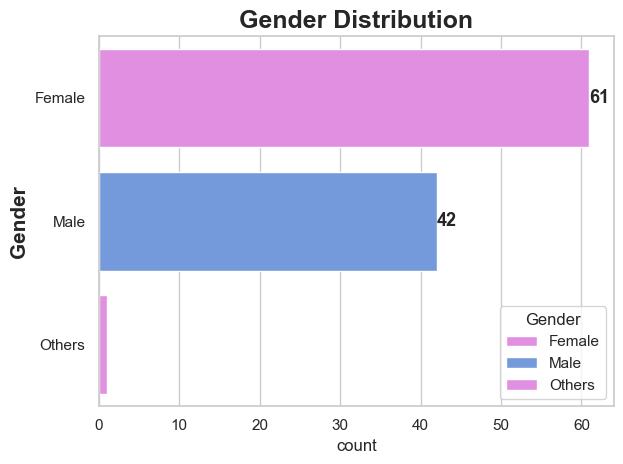

In [109]:
# 2. Gender Distribution
ax=sns.countplot(data=df,y='Gender',hue='Gender',palette=['#ee82ee','#6495ed'])
ax.bar_label(ax.containers[0],fontsize='13',fontweight='bold')
ax.bar_label(ax.containers[1],fontsize='13',fontweight='bold')
plt.title("Gender Distribution",fontsize='18',fontweight='bold')
plt.ylabel("Gender",fontsize='15',fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plots/gender_distribution.png", dpi=300)
plt.show()

2### SHOPPING BEHAVIOUR

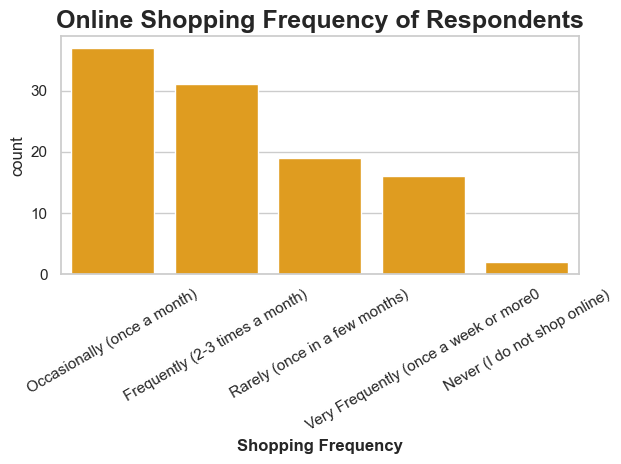

In [110]:
# 3. Shopping Frequency
counts=df['Shopping_Frequency'].value_counts()
sns.barplot(counts,color='orange')
plt.title("Online Shopping Frequency of Respondents", fontsize='18', fontweight='bold')
plt.xlabel("Shopping Frequency",fontsize='12',fontweight='bold')
plt.xticks(rotation=30)
#plt.legend()
plt.tight_layout()
plt.savefig("plots/Online_Shopping_Frequency_of_Respondents.png", dpi=300)
plt.show()

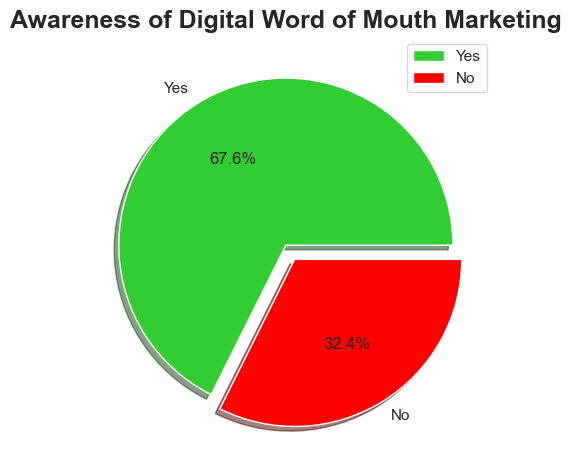

In [111]:
# 4. WOM Awareness
counts=data=df['WOM_Awareness'].value_counts()
colors=['#32cd32','#ff0000']
explode=[0,0.1]
plt.pie(counts,labels=counts.index,colors=colors,autopct='%1.1f%%',shadow=True,explode=explode)
plt.title("Awareness of Digital Word of Mouth Marketing",fontsize='18',fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig("plots/Awareness_of_WOM.png", dpi=300)
plt.show()

### PLATFORM TRUST

C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\1332780309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


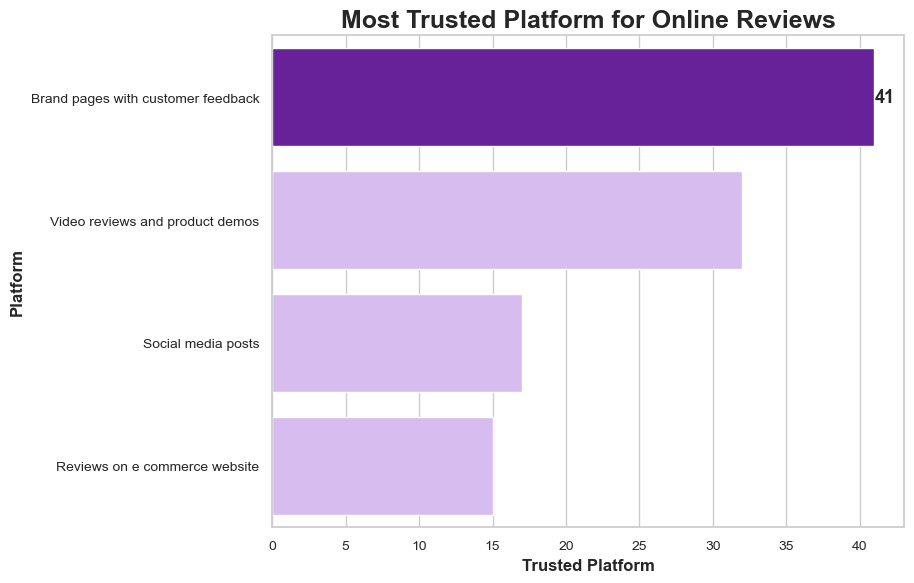

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

count = df['trusted_platform'].value_counts()

# colors
colors = ['#d8b4f8'] * len(count)
max_index = count.values.argmax()
colors[max_index] = '#6a0dad'

plt.figure(figsize=(10,6))   # 👈 bigger size

# plot
ax = sns.barplot(
    y=count.index,
    x=count.values,
    palette=colors
)

# values on bars
ax.bar_label(ax.containers[0], fontsize=13, fontweight='bold')

# titles & labels
plt.title("Most Trusted Platform for Online Reviews",
          fontsize=18, fontweight='bold')

plt.xlabel("Trusted Platform", fontsize=12, fontweight='bold')
plt.ylabel("Platform", fontsize=12, fontweight='bold')

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# 🔥 MAIN FIXES
plt.tight_layout()
plt.subplots_adjust(left=0.35)   # 👈 left space for long names

plt.savefig(
    "plots/Trusted_Platform.png",
    dpi=300,
    bbox_inches='tight',   # 👈 no cut
    pad_inches=0.3
)

plt.show()

### REVIEW BEHAVIOUR

C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\3135921397.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count.values, y=count.index, palette=colors)


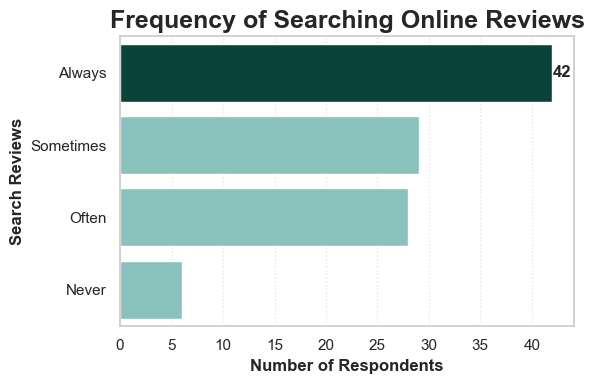

In [113]:
# 6. Review Searching Behaviour

import seaborn as sns
import matplotlib.pyplot as plt

count = df['reviews'].value_counts()

# sab bars ke liye light color
colors = ['#80cbc4'] * len(count)

# highest value ka index
max_index = count.values.argmax()

# usko dark color
colors[max_index] = '#004d40'   # dark teal highlight

plt.figure(figsize=(6,4))

# horizontal bar plot
ax = sns.barplot(x=count.values, y=count.index, palette=colors)

# 👉 values show kar (bars ke end pe)
ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold')

plt.title("Frequency of Searching Online Reviews", fontsize=18, fontweight='bold')
plt.xlabel("Number of Respondents", fontsize=12, fontweight='bold')
plt.ylabel("Search Reviews", fontsize=12, fontweight='bold')

plt.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("plots/Frequency_of_Searching_Online_Reviews.png", dpi=300)
plt.show()

C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\2902926200.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=count.index, y=count.values, palette=colors)


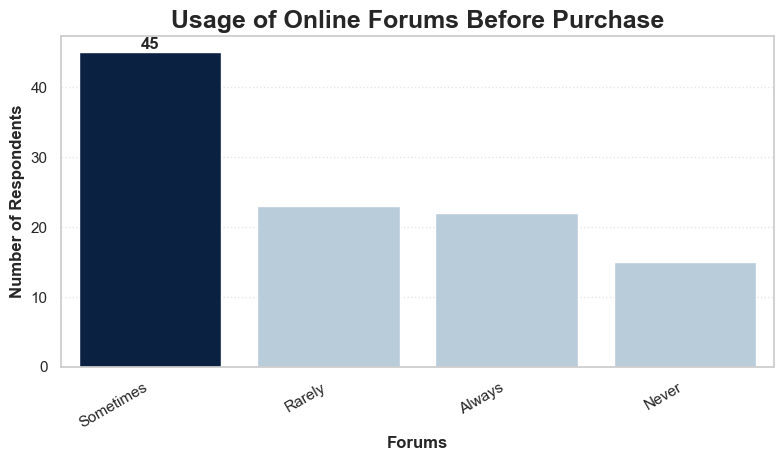

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

count = df['forums'].value_counts()

# colors
colors = ['#b3cde0'] * len(count)
max_index = count.values.argmax()
colors[max_index] = '#011f4b'

plt.figure(figsize=(8,5))   # 👈 thoda bada

# plot
ax = sns.barplot(x=count.index, y=count.values, palette=colors)

# values on top
ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold')

# titles
plt.title("Usage of Online Forums Before Purchase",
          fontsize=18, fontweight='bold')

plt.xlabel("Forums", fontsize=12, fontweight='bold')
plt.ylabel("Number of Respondents", fontsize=12, fontweight='bold')

# 👉 IMPORTANT (labels cut fix)
plt.xticks(rotation=30, ha='right')   # 👈 align right

plt.grid(axis='y', linestyle=':', alpha=0.5)

# 🔥 MAIN FIXES
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)   # 👈 bottom space for rotated labels

plt.savefig(
    "plots/Usage_of_Online_Forums_Before_Purchase.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.3
)

plt.show()

### TRUST ANALYSIS

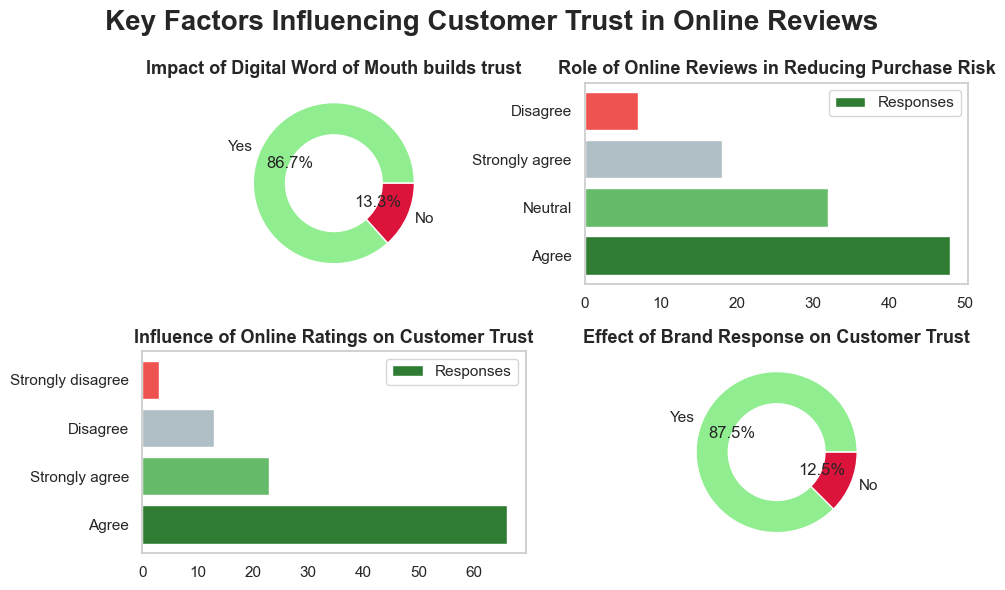

In [115]:
# 8. Trust in Reviews
fig, ax=plt.subplots(2,2,figsize=(10,6))
fig.suptitle("Key Factors Influencing Customer Trust in Online Reviews", fontsize='20',fontweight='bold')
'''
count=df['trust_builded'].value_counts()
ax[0,0].barh(count.index,count.values,color=["#90ee90","#dc143c"],label="Responses",edgecolor='white')
ax[0,0].set_title("Impact of Digital Word of Mouth builds trust", fontsize='13',fontweight='bold')
#ax[0,0].set_xlabel("Number of Respondents",fontsize='11',fontweight='bold')
ax[0,0].legend()
ax[0,0].grid(False)
'''
count = df['trust_builded'].value_counts()

ax[0,0].pie(count.values,
            labels=count.index,
            colors=["#90ee90","#dc143c"],
            autopct='%1.1f%%')

# donut hole
centre_circle = plt.Circle((0,0), 0.6, fc='white')
ax[0,0].add_artist(centre_circle)

ax[0,0].set_title("Impact of Digital Word of Mouth builds trust", fontsize=13, fontweight='bold')

count=df['trust_builded2'].value_counts()
ax[0,1].barh(count.index,count.values,color=["#2E7D32","#66BB6A","#B0BEC5","#EF5350","#C62828"],label="Responses",edgecolor="white")
ax[0,1].set_title("Role of Online Reviews in Reducing Purchase Risk", fontsize='13',fontweight='bold')
ax[0,1].legend()
ax[0,1].grid(False)

count=df['trust_builded3'].value_counts()
ax[1,0].barh(count.index,count.values,color=["#2E7D32","#66BB6A","#B0BEC5","#EF5350","#C62828"],label="Responses",edgecolor="white")
ax[1,0].set_title("Influence of Online Ratings on Customer Trust",fontsize='13',fontweight='bold')
ax[1,0].legend()
ax[1,0].grid(False)

count = df['trust_builded4'].value_counts()

ax[1,1].pie(count.values,
            labels=count.index,
            colors=["#90ee90","#dc143c"],
            autopct='%1.1f%%')

# donut hole
centre_circle = plt.Circle((0,0), 0.6, fc='white')
ax[1,1].add_artist(centre_circle)

ax[1,1].set_title("Effect of Brand Response on Customer Trust", fontsize=13, fontweight='bold')
'''
count=df['trust_builded4'].value_counts()
ax[1,1].barh(count.index,count.values,color=["#90ee90","#dc143c"],label="Responses",edgecolor='white')
ax[1,1].set_title("Effect of Brand Response on Customer Trust", fontsize='13',fontweight='bold')
ax[1,1].legend()
ax[1,1].grid(False)
'''
plt.tight_layout()
plt.savefig("plots/Factors_Influencing_Customer_Trust.png", dpi=300)
plt.show()

This chart combines multiple factors such as digital word of mouth, brand response, ratings, and risk reduction to analyze their overall impact on customer trust.

C:\Users\sneha\AppData\Local\Temp\ipykernel_28684\2615627928.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


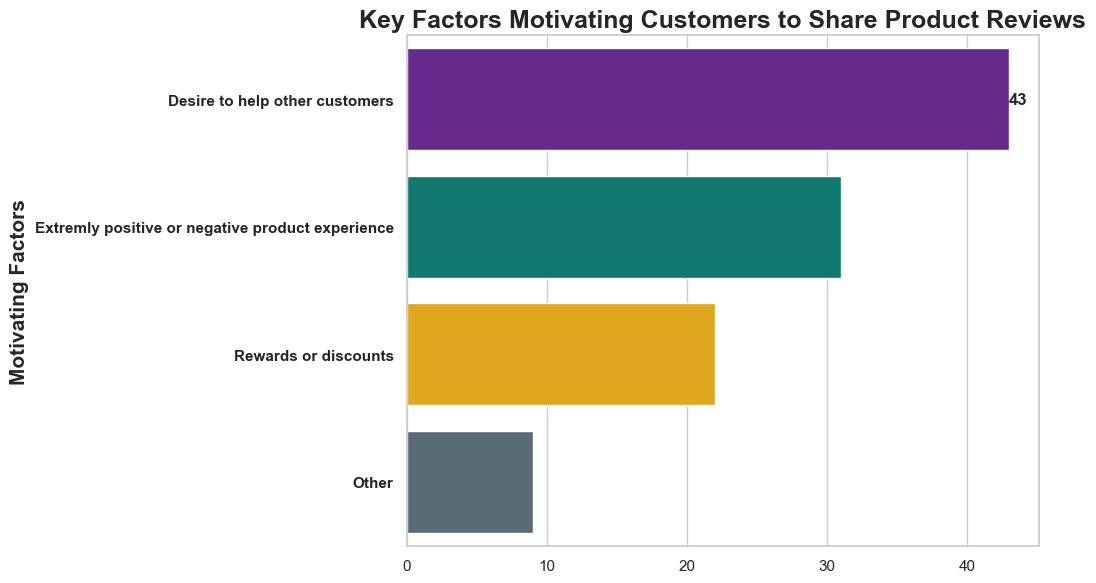

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

count = df["What motivates you the most to share product reviews."].value_counts()

plt.figure(figsize=(10,6))   # 👈 size increase

ax = sns.barplot(
    y=count.index,
    x=count.values,
    palette=["#6A1B9A","#00897B","#FFB300","#546E7A"],
    edgecolor="white"
)

# labels
plt.title("Key Factors Motivating Customers to Share Product Reviews",
          fontsize=18, fontweight='bold')

plt.ylabel("Motivating Factors", fontsize=15, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

# 👇 values on bars (extra polish)
ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold')

# 👇 MOST IMPORTANT FIXES
plt.tight_layout()
plt.subplots_adjust(left=0.35)   # 👈 left space for long labels

plt.savefig(
    "plots/Factors_Motivating_Customers.png",
    dpi=300,
    bbox_inches='tight',   # 👈 no cut
    pad_inches=0.3
)

plt.show()

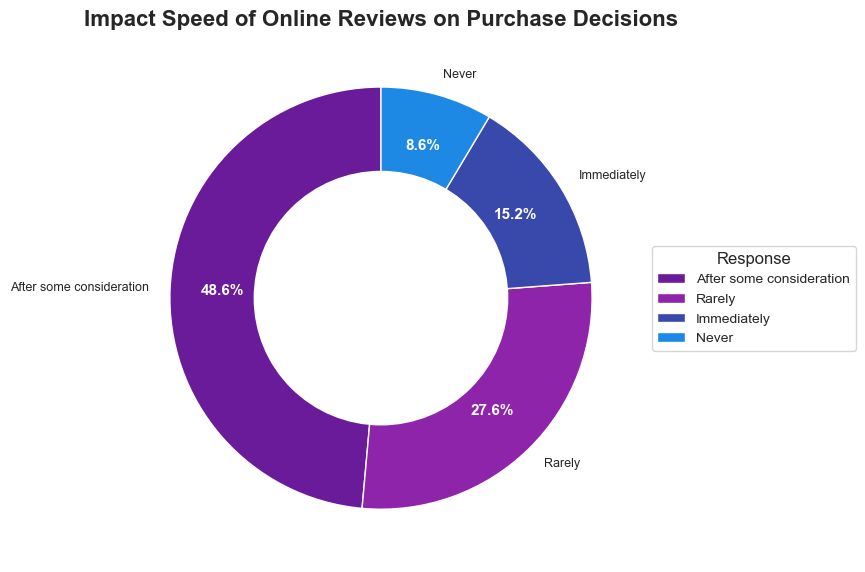

In [122]:
import matplotlib.pyplot as plt

count = df["How quickly do online reviews influence your final purchase."].value_counts()

colors = ["#6A1B9A", "#8E24AA", "#3949AB", "#1E88E5"]

plt.figure(figsize=(8,7))   # 👈 size thoda bada

wedges, texts, autotexts = plt.pie(
    count.values,
    labels=count.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

# 👉 Donut hole
centre_circle = plt.Circle((0,0), 0.6, fc='white')
plt.gca().add_artist(centre_circle)

# 👉 Bold % values
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# 👉 Labels styling
for text in texts:
    text.set_fontsize(9)

# ❗ IMPORTANT: legend ko bahar shift karo
plt.legend(
    wedges,
    count.index,
    title="Response",
    loc="center left",
    bbox_to_anchor=(1, 0.5),   # 👈 right side outside
    fontsize=10
)

plt.title("Impact Speed of Online Reviews on Purchase Decisions",
          fontsize=16,
          fontweight='bold')

# ❗ MOST IMPORTANT FIXES
plt.tight_layout()

plt.savefig(
    "plots/Impact_Speed_of_Online_Reviews_on_Purchase_Decisions.png",
    dpi=300,
    bbox_inches='tight',   # 👈 cut fix
    pad_inches=0.4         # 👈 extra spacing
)

plt.show()

In [23]:
# 11. Reviews reduce risk

In [24]:
# 12. Reviews influence speed

### USER ENGAGEMENT

In [25]:
# 13. Motivation to write reviews

In [26]:
# 14. Age vs Recommendation/Trust